In [44]:
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from PIL import Image
import torchvision.transforms as T
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torchvision.ops as ops
import torch
import numpy as np

In [45]:
def get_loaded_model(checkpoint_path, num_classes, device):
    model = fasterrcnn_resnet50_fpn(weights=None) 
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
        in_features, num_classes
    )
    
    state_dict = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(state_dict)
    
    model.to(device)
    model.eval() 
    return model

In [46]:
DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
PATH_TO_PTH = "checkpoints/best.pth"
PATH_TO_IMG = r"btl/data\test\ISIC_0000477_jpg.rf.fdbb3f6ba3f6a7b666251338f918d802.jpg" 
MY_NUM_CLASSES = 2

idx_to_class = {1: "skin care "} 

model = get_loaded_model(PATH_TO_PTH, MY_NUM_CLASSES, DEVICE)

# 2. Load và tiền xử lý ảnh
test_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

img_pil = Image.open(PATH_TO_IMG).convert("RGB")
img_tensor = test_transform(img_pil).to(DEVICE) # Dùng transform mới

with torch.no_grad():
    prediction = model([img_tensor])



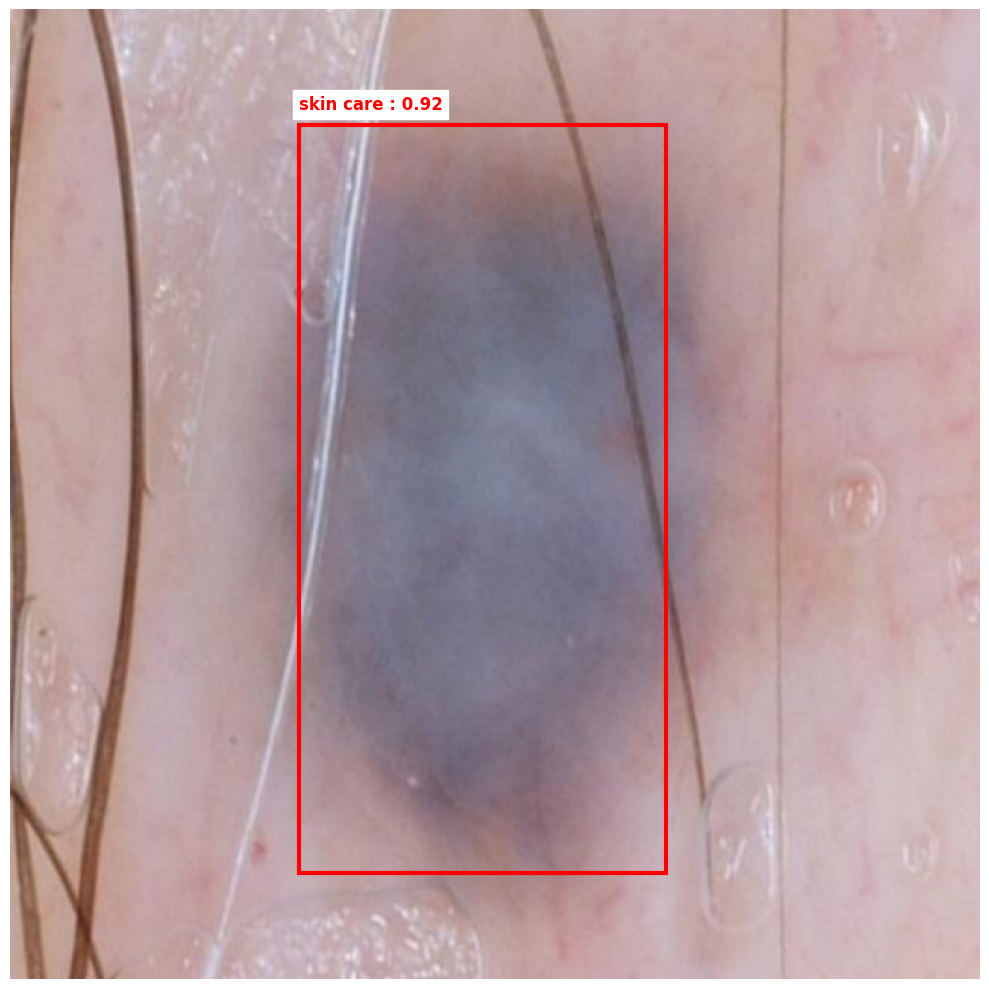

In [47]:

def visualize_prediction(image, output, idx_to_class=None, conf_threshold=0.5, iou_threshold=0.3):
    # 1. Chuyển tensor sang CPU
    boxes = output["boxes"].cpu()
    labels = output["labels"].cpu()
    scores = output["scores"].cpu()

    # 2. Áp dụng NMS để lọc trùng
    keep_idx = ops.nms(boxes, scores, iou_threshold)
    boxes = boxes[keep_idx]
    labels = labels[keep_idx]
    scores = scores[keep_idx]

    image_np = image.permute(1, 2, 0).cpu().numpy()
    
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    image_np = (image_np * std) + mean
    image_np = np.clip(image_np, 0, 1) # Đưa về dải [0, 1] hợp lệ cho imshow

    # 4. Bắt đầu vẽ
    fig, ax = plt.subplots(1, figsize=(10, 10))
    ax.imshow(image_np)

    found_any = False
    for box, label, score in zip(boxes, labels, scores):
        if score < conf_threshold:
            continue
        
        found_any = True
        xmin, ymin, xmax, ymax = box.numpy()
        
        # Vẽ khung màu đỏ, nét dày 3 cho rõ
        rect = patches.Rectangle(
            (xmin, ymin), xmax - xmin, ymax - ymin,
            linewidth=3, edgecolor='red', facecolor='none'
        )
        ax.add_patch(rect)
        
        # Text label với nền trắng cho dễ đọc
        class_name = idx_to_class[label.item()] if idx_to_class else str(label.item())
        ax.text(xmin, ymin - 10, f"{class_name}: {score:.2f}",
                color='red', fontsize=12, fontweight='bold', 
                backgroundcolor='white')

    if not found_any:
        print(f"Không có kết quả nào > {conf_threshold}")

    plt.axis("off")
    plt.tight_layout()
    plt.show()

# --- GỌI HÀM ---
visualize_prediction(
    img_tensor, 
    prediction[0], 
    idx_to_class=idx_to_class, 
    conf_threshold=0.5, 
    iou_threshold=0.3  
)